In [37]:
from ultralytics import YOLO
import os
import glob
import shutil
import pandas as pd

model_path = "runs/detect/Bottle_Detection_Project/bottle_yolov8n/weights/best.pt"

model = YOLO(model_path)

print("Model loaded successfully!")
print("Classes:", model.names)

Model loaded successfully!
Classes: {0: 'bottle'}


In [38]:
test_images = glob.glob(
    "Bottle_Detection_Project/roboflow_dataset/test/images/*"
)

print("Number of test images:", len(test_images))
print(test_images[:5])

Number of test images: 20
['Bottle_Detection_Project/roboflow_dataset/test/images\\bottle003_jpg.rf.15f3558fe0ba0f693650f8dd2217c848.jpg', 'Bottle_Detection_Project/roboflow_dataset/test/images\\bottle028_jpg.rf.ba92208fe3c2124c3544320a6719d235.jpg', 'Bottle_Detection_Project/roboflow_dataset/test/images\\bottle032_jpg.rf.746b3ab5123d8b6a3c50bcdfd432f2f5.jpg', 'Bottle_Detection_Project/roboflow_dataset/test/images\\bottle044_jpg.rf.46fde1abb0590eb210747bb8728e57c5.jpg', 'Bottle_Detection_Project/roboflow_dataset/test/images\\bottle057_jpg.rf.330257f43b8c608d53c7b385d2e91015.jpg']


In [39]:
source_images = "Bottle_Detection_Project/roboflow_dataset/test/images"
source_labels = "Bottle_Detection_Project/roboflow_dataset/test/labels"

clean_images = "Bottle_Detection_Project/clean_test/images"
clean_labels = "Bottle_Detection_Project/clean_test/labels"

os.makedirs(clean_images, exist_ok=True)
os.makedirs(clean_labels, exist_ok=True)

# Copy test images
for file in os.listdir(source_images):
    shutil.copy(
        os.path.join(source_images, file),
        os.path.join(clean_images, file)
    )

print("Test images copied:", len(os.listdir(clean_images)))

Test images copied: 20


In [40]:
label_files = glob.glob(source_labels + "/*.txt")

for file in label_files:

    output_file = os.path.join(
        clean_labels,
        os.path.basename(file)
    )

    clean_lines = []

    with open(file, "r") as f:
        for line in f:

            parts = line.strip().split()

            # Keep only YOLO detection format
            if len(parts) != 5:
                continue

            # Our trained model has only one class: bottle
            parts[0] = "0"

            clean_lines.append(" ".join(parts))

    with open(output_file, "w") as f:
        f.write("\n".join(clean_lines))

print("Labels cleaned successfully!")

Labels cleaned successfully!


In [41]:
clean_yaml = """
path: Bottle_Detection_Project/clean_test
test: images

nc: 1
names: ['bottle']
"""

with open(
    "Bottle_Detection_Project/clean_test/data.yaml",
    "w"
) as f:
    f.write(clean_yaml)

print("Evaluation YAML created!")

Evaluation YAML created!


In [28]:
import os

result_folder = "runs/detect/predict"

print("Saved results:")
print(os.listdir(result_folder)[:10])

Saved results:
['109_jpg.rf.afb5d712b9d469ac6e266fbd59c80f16.jpg', '11_jpg.rf.2e311f822818ef4167f098dd2c7481bb.jpg', '131_jpg.rf.b6d5e88ba4a79c8f65d5c8ac9d4b97cc.jpg', '135_jpg.rf.a87e765a4dcd076263b4b74ee19bf3a7.jpg', '136_jpg.rf.8a5e60d53ce29e5e74b4770e4c8f4c1b.jpg', '143_jpg.rf.36098d1c6df196ef1fdfd65ee26c3194.jpg', '148_jpg.rf.8bad764191246a0872917a3a3bea8b5e.jpg', '165_jpg.rf.e889134a94f5994d61eedaefcd1ff2d3.jpg', '173_jpg.rf.a9b4a5b5265f2dfa5c004e03ca4345c6.jpg', '190_jpg.rf.3b0f02f52ddd5038f785d41bc21aaf43.jpg']


In [30]:
from pathlib import Path

yaml_path = Path("Bottle_Detection_Project/roboflow_dataset/data.yaml")

print("data.yaml exists:", yaml_path.exists())

if yaml_path.exists():
    print(yaml_path.read_text())

data.yaml exists: True
train: ../train/images
val: ../valid/images
test: ../test/images

nc: 3
names: ['Bottle-Detection', 'botle', 'bottlr']

roboflow:
  workspace: eman-fatima-e1ncy
  project: bottle-detection-7gu4t
  version: 1
  license: CC BY 4.0
  url: https://universe.roboflow.com/eman-fatima-e1ncy/bottle-detection-7gu4t/dataset/1


In [42]:
clean_yaml = """
path: Bottle_Detection_Project/clean_test
train: images
val: images
test: images

nc: 1
names: ['bottle']
"""

with open(
    "Bottle_Detection_Project/clean_test/data.yaml",
    "w"
) as f:
    f.write(clean_yaml)

print("data.yaml updated successfully!")

data.yaml updated successfully!
ERROR! Session/line number was not unique in database. History logging moved to new session 269


In [43]:
metrics = model.val(
    data="Bottle_Detection_Project/clean_test/data.yaml",
    split="test"
)

print("Evaluation completed!")

Ultralytics 8.4.115  Python-3.13.7 torch-2.13.0+cpu CPU (Intel Core i5-5300U 2.30GHz)
val: Fast image access  (ping: 0.20.0 ms, read: 50.027.5 MB/s, size: 1141.0 KB)
val: Scanning C:\Users\Localws\Bottle_Detection_Project\clean_test\labels... 20 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 20/20 94.0it/s 0.2s8s
val: New cache created: C:\Users\Localws\Bottle_Detection_Project\clean_test\labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 3.1s/it 6.2s<16.7s
                   all         20         71      0.543      0.577      0.535      0.279
Speed: 1.7ms preprocess, 65.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to C:\Users\Localws\runs\detect\val-16
Evaluation completed!


In [44]:
precision = metrics.box.mp
recall = metrics.box.mr
map50 = metrics.box.map50
map5095 = metrics.box.map

print("Precision:", precision)
print("Recall:", recall)
print("mAP@50:", map50)
print("mAP@50-95:", map5095)

Precision: 0.5429395491088681
Recall: 0.5774647887323944
mAP@50: 0.5348673534310038
mAP@50-95: 0.2788802243824062


In [45]:
prediction_results = model.predict(
    source=clean_images,
    conf=0.5,
    save=True
)

print("Predictions completed!")


image 1/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle003_jpg.rf.15f3558fe0ba0f693650f8dd2217c848.jpg: 224x320 5 bottles, 89.3ms
image 2/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle028_jpg.rf.ba92208fe3c2124c3544320a6719d235.jpg: 320x224 2 bottles, 80.6ms
image 3/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle032_jpg.rf.746b3ab5123d8b6a3c50bcdfd432f2f5.jpg: 224x320 (no detections), 55.2ms
image 4/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle044_jpg.rf.46fde1abb0590eb210747bb8728e57c5.jpg: 320x224 1 bottle, 74.5ms
image 5/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle057_jpg.rf.330257f43b8c608d53c7b385d2e91015.jpg: 224x320 5 bottles, 54.7ms
image 6/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle065_jpg.rf.bd445e8ce5ea6033ff9482f44264153d.jpg: 320x256 1 bottle, 77.7ms
image 7/20 C:\Users\Localws\Bottle_Detection_Project\clean_test\images\bottle079_jp

In [46]:
def calculate_iou(box1, box2):
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])

    intersection = max(0, x2 - x1) * max(0, y2 - y1)

    area1 = max(0, box1[2] - box1[0]) * max(0, box1[3] - box1[1])
    area2 = max(0, box2[2] - box2[0]) * max(0, box2[3] - box2[1])

    union = area1 + area2 - intersection

    if union == 0:
        return 0

    return intersection / union

In [47]:
import cv2

correct_total = 0
missed_total = 0
false_total = 0

image_results = []

for image_path in test_images:

    # Corresponding label
    image_name = os.path.splitext(os.path.basename(image_path))[0]
    label_path = os.path.join(
        clean_labels,
        image_name + ".txt"
    )

    # Read ground-truth boxes
    ground_truth = []

    if os.path.exists(label_path):

        image = cv2.imread(image_path)
        height, width = image.shape[:2]

        with open(label_path, "r") as f:

            for line in f:

                parts = line.strip().split()

                if len(parts) != 5:
                    continue

                _, xc, yc, w, h = map(float, parts)

                x1 = (xc - w / 2) * width
                y1 = (yc - h / 2) * height
                x2 = (xc + w / 2) * width
                y2 = (yc + h / 2) * height

                ground_truth.append(
                    [x1, y1, x2, y2]
                )

    # Prediction
    result = model.predict(
        image_path,
        conf=0.5,
        verbose=False
    )[0]

    predictions = []

    if result.boxes is not None:

        for box in result.boxes.xyxy.cpu().numpy():
            predictions.append(box.tolist())

    matched_gt = set()
    correct = 0
    false = 0

    for pred in predictions:

        best_iou = 0
        best_gt = -1

        for i, gt in enumerate(ground_truth):

            if i in matched_gt:
                continue

            iou = calculate_iou(pred, gt)

            if iou > best_iou:
                best_iou = iou
                best_gt = i

        if best_iou >= 0.5:
            correct += 1
            matched_gt.add(best_gt)
        else:
            false += 1

    missed = len(ground_truth) - len(matched_gt)

    correct_total += correct
    missed_total += missed
    false_total += false

    image_results.append({
        "Image": os.path.basename(image_path),
        "Correct": correct,
        "Missed": missed,
        "False": false
    })

print("Correct detections:", correct_total)
print("Missed detections:", missed_total)
print("False detections:", false_total)

Correct detections: 24
Missed detections: 47
False detections: 8


In [48]:
error_df = pd.DataFrame(image_results)

error_df

,Image,Correct,Missed,False
0,bottle003_jpg.rf.15f3558fe0ba0f693650f8dd2217c...,2,13,3
1,bottle028_jpg.rf.ba92208fe3c2124c3544320a6719d...,1,0,1
2,bottle032_jpg.rf.746b3ab5123d8b6a3c50bcdfd432f...,0,3,0
3,bottle044_jpg.rf.46fde1abb0590eb210747bb8728e5...,1,1,0
4,bottle057_jpg.rf.330257f43b8c608d53c7b385d2e91...,5,7,0
5,bottle065_jpg.rf.bd445e8ce5ea6033ff9482f442641...,1,0,0
6,bottle079_jpg.rf.4c5b3311d77806a51557f653f662b...,2,0,0
7,bottle100_jpg.rf.53bd12422d846e60793f5fd5dd176...,0,9,2
8,bottle120_jpg.rf.6fb987dba762ace847b5983b61d2e...,1,1,0
9,bottle134_jpg.rf.b8e6c5fd903749873add11648f6ce...,1,0,0


In [49]:
error_df["Total Errors"] = (
    error_df["Missed"] + error_df["False"]
)

difficult_examples = error_df.sort_values(
    "Total Errors",
    ascending=False
).head(5)

difficult_examples

,Image,Correct,Missed,False,Total Errors
0,bottle003_jpg.rf.15f3558fe0ba0f693650f8dd2217c...,2,13,3,16
7,bottle100_jpg.rf.53bd12422d846e60793f5fd5dd176...,0,9,2,11
14,bottle169_jpg.rf.bca253e0d0269b737509f65dc5940...,2,8,0,8
19,bottle189_jpg.rf.f84fe96658a459e97a7713869a51c...,0,5,2,7
4,bottle057_jpg.rf.330257f43b8c608d53c7b385d2e91...,5,7,0,7


bottle003_jpg.rf.15f3558fe0ba0f693650f8dd2217c848.jpg


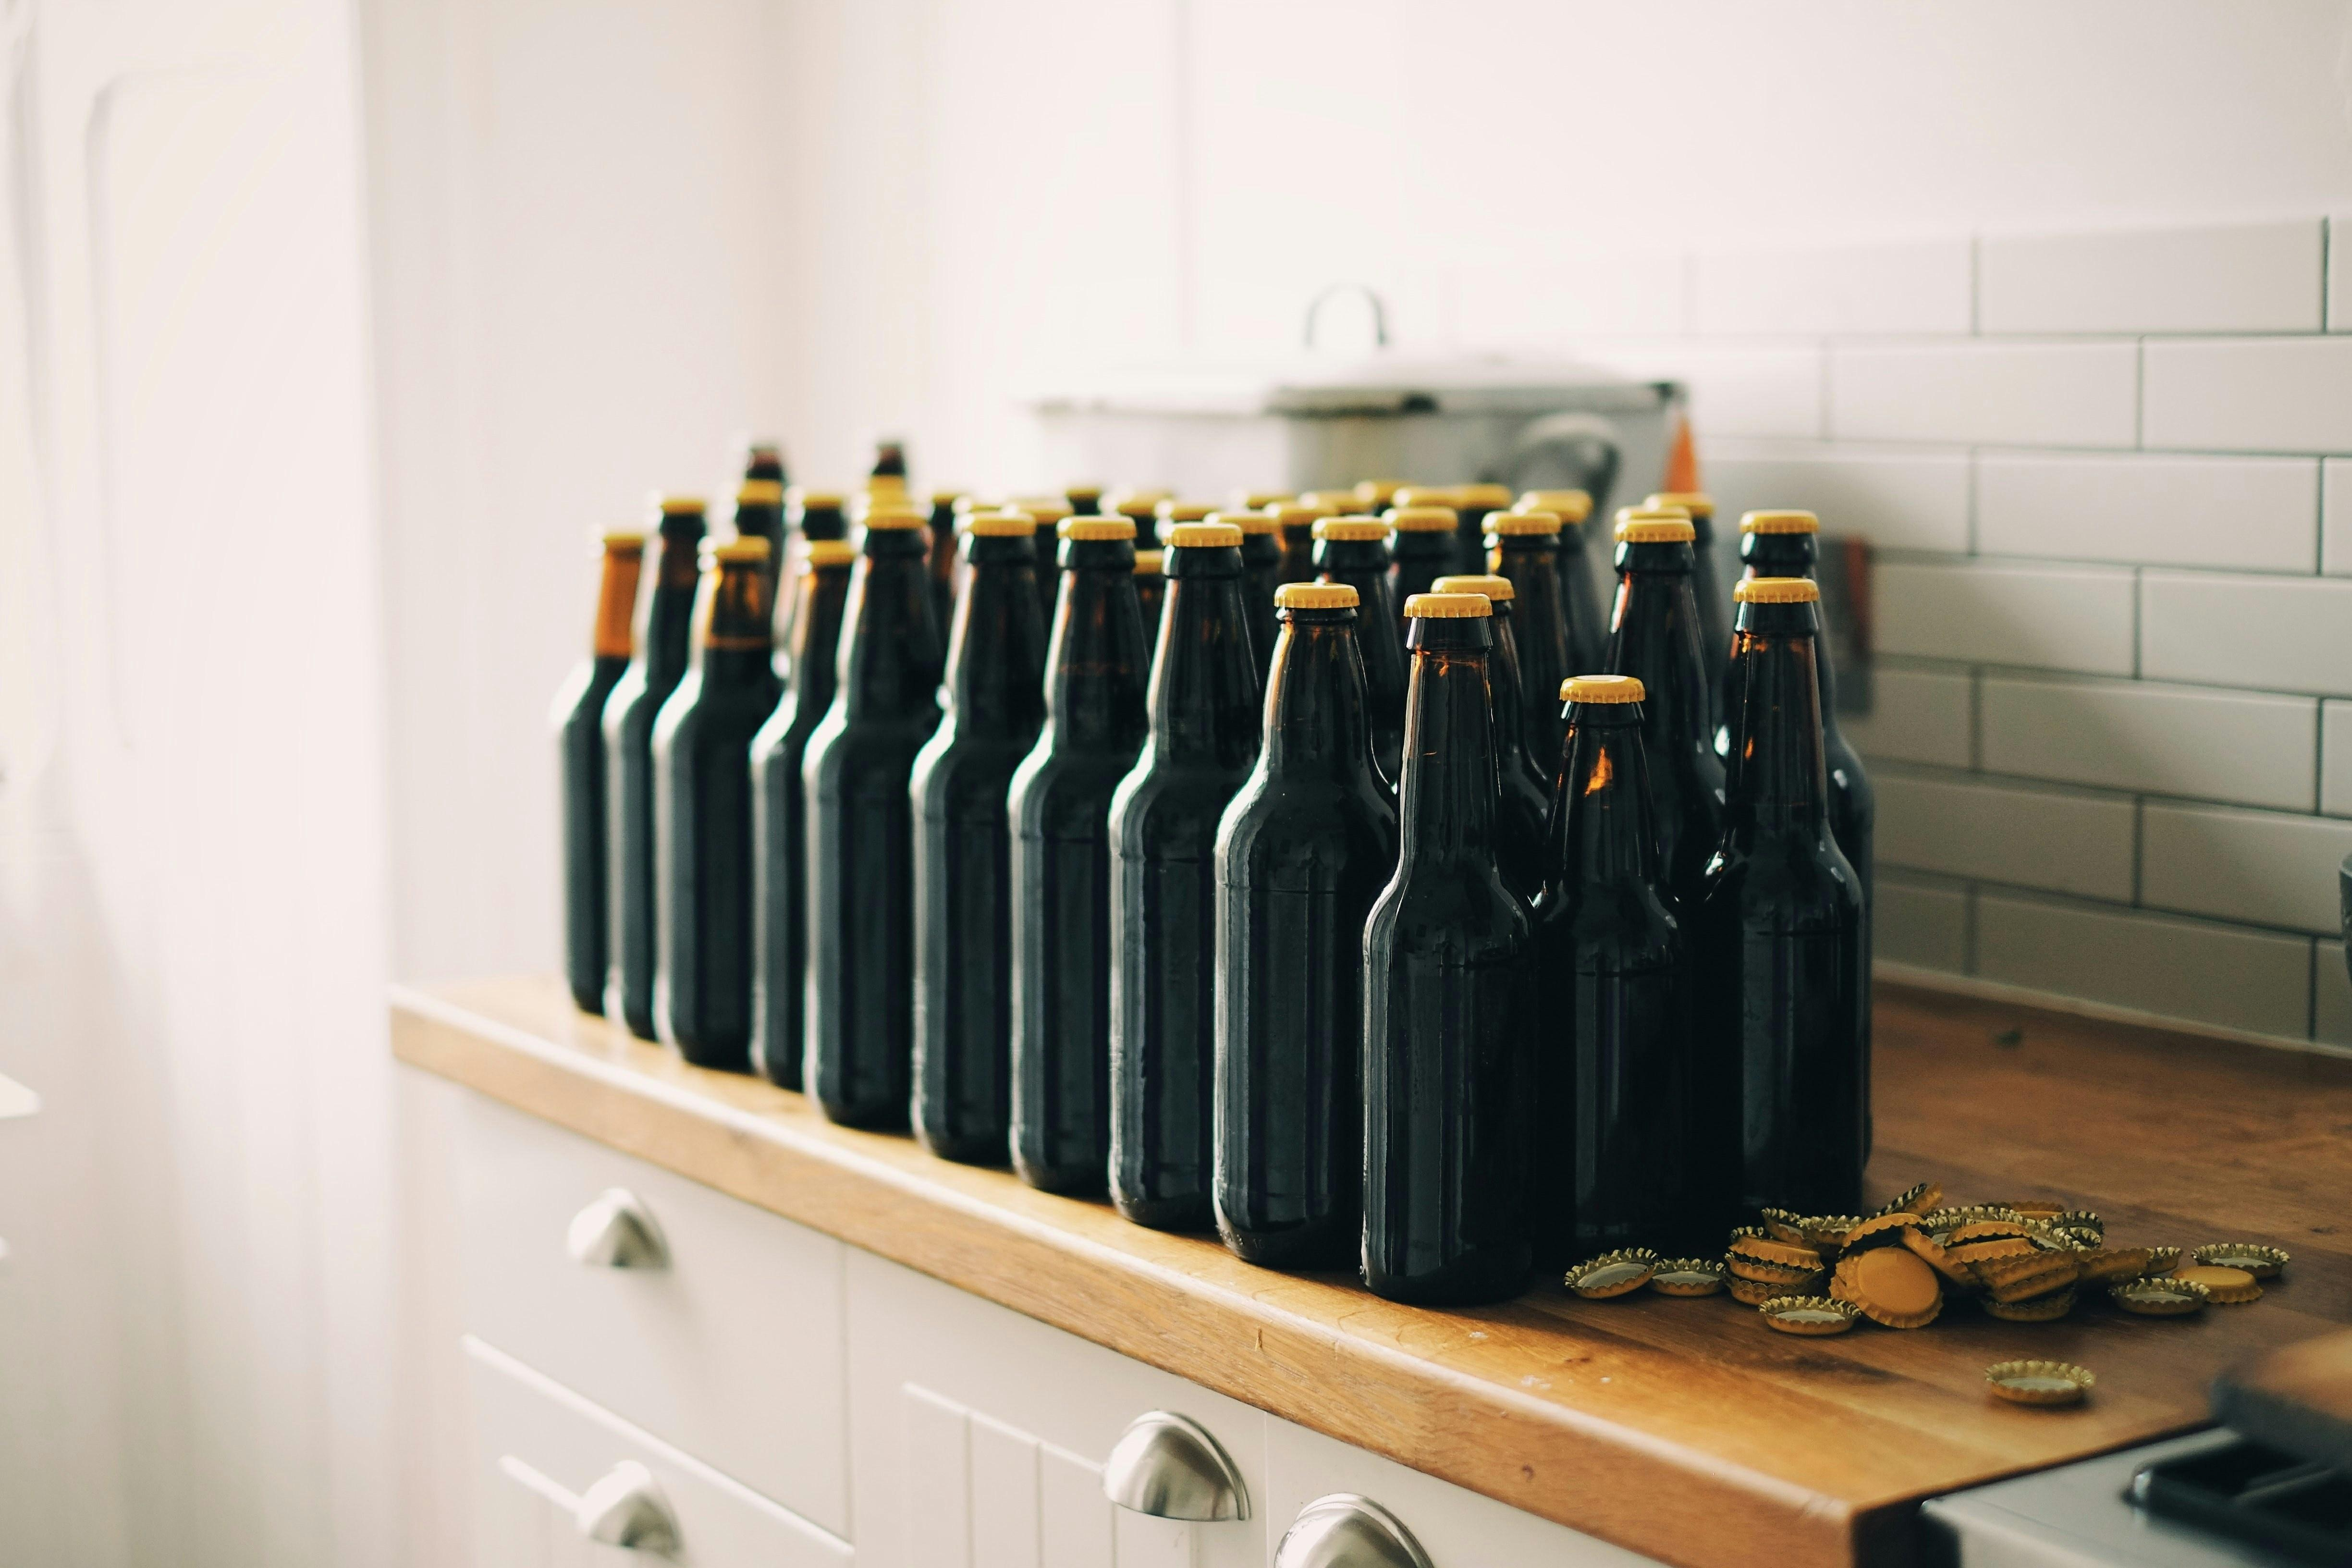

bottle100_jpg.rf.53bd12422d846e60793f5fd5dd1764a6.jpg


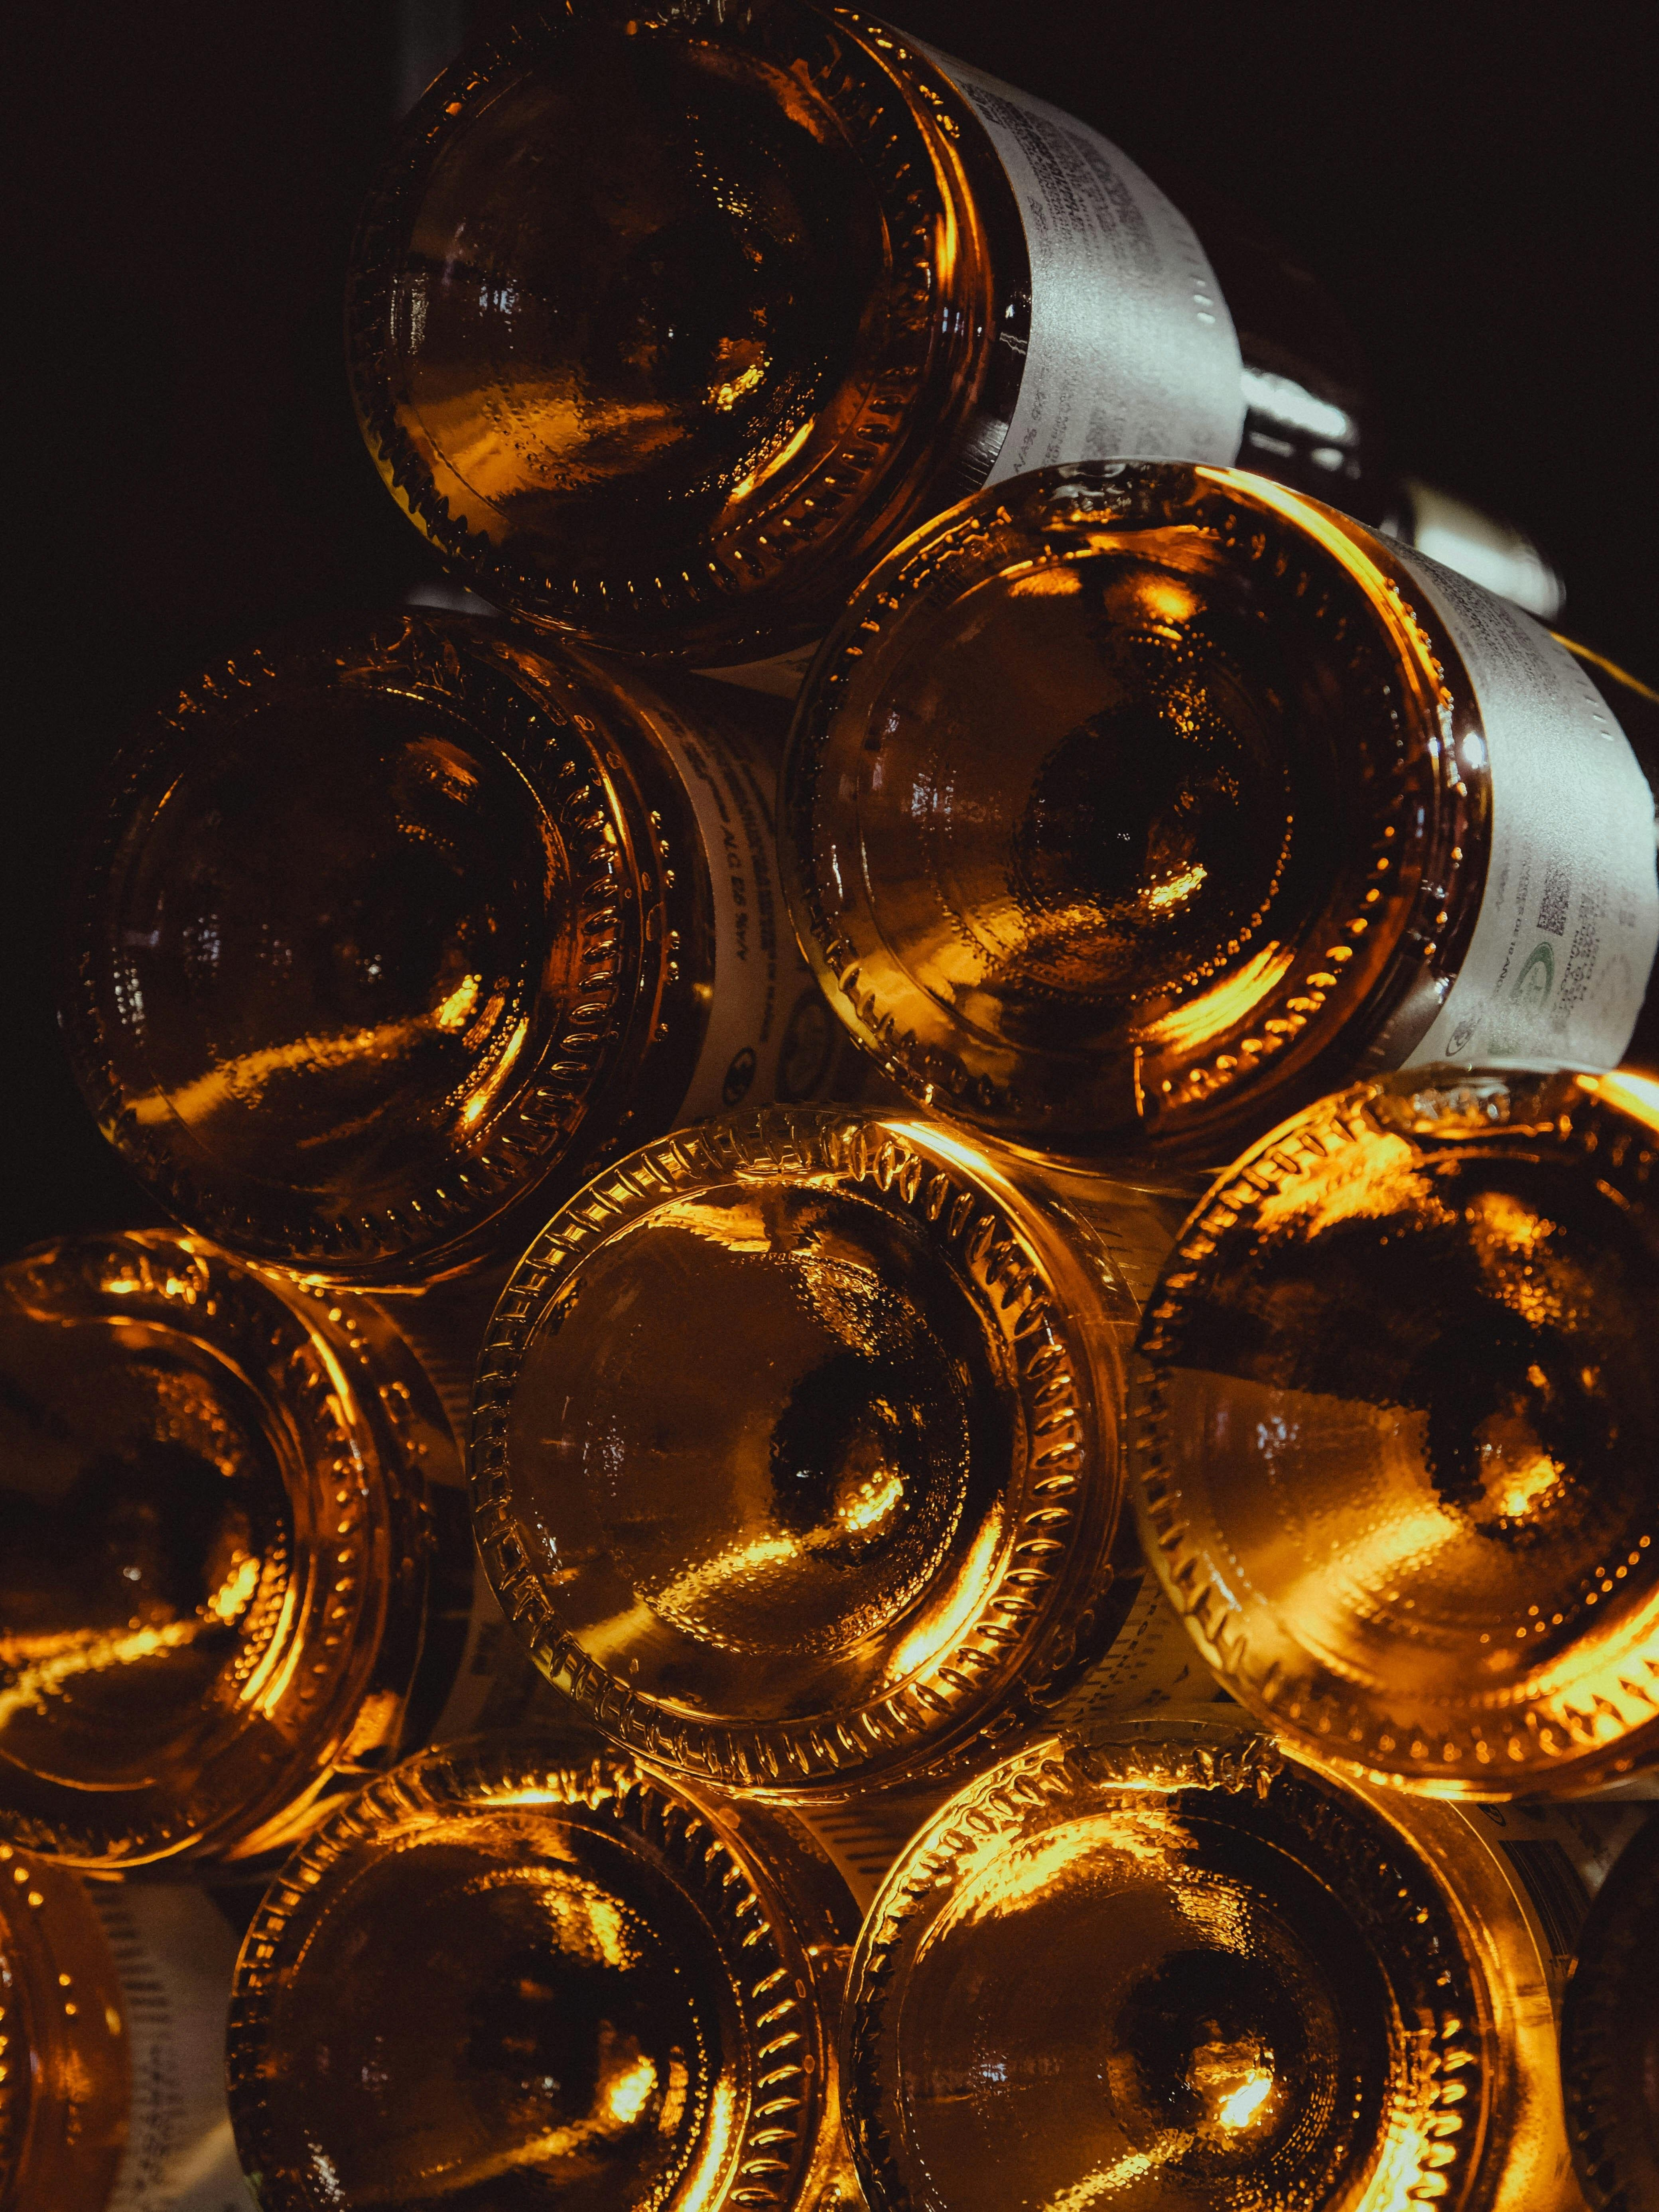

bottle169_jpg.rf.bca253e0d0269b737509f65dc5940f89.jpg


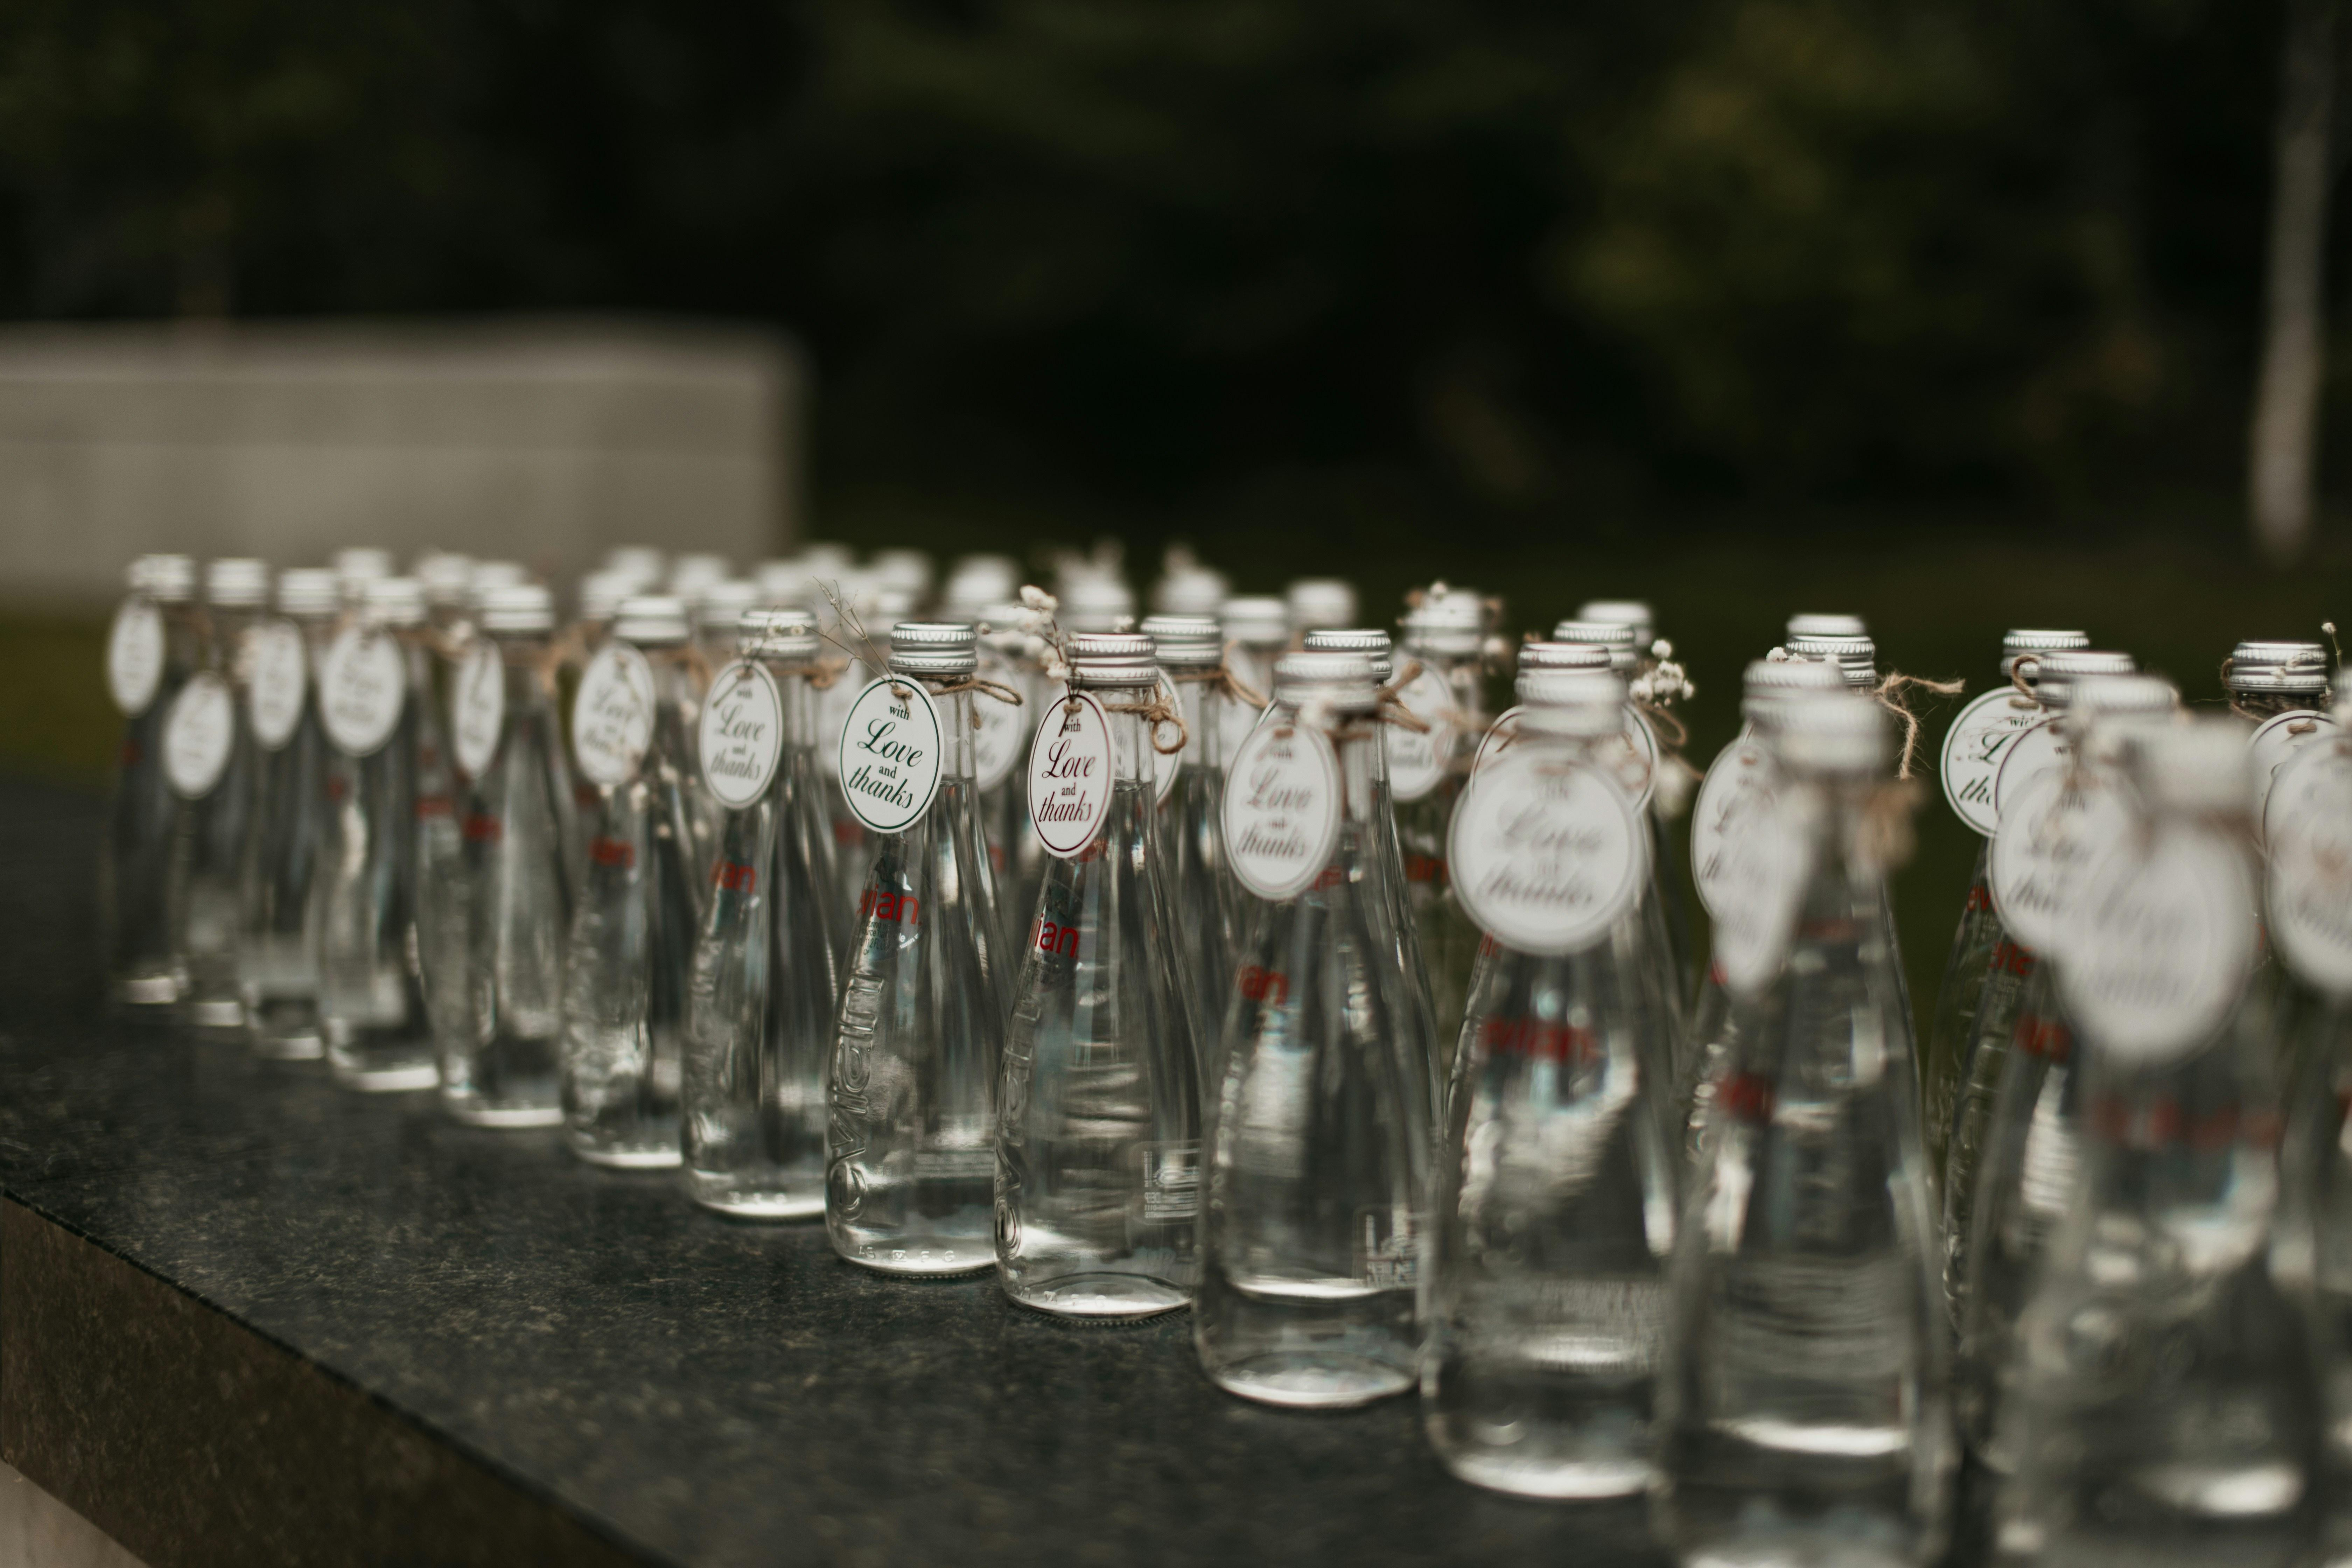

bottle189_jpg.rf.f84fe96658a459e97a7713869a51cb2e.jpg


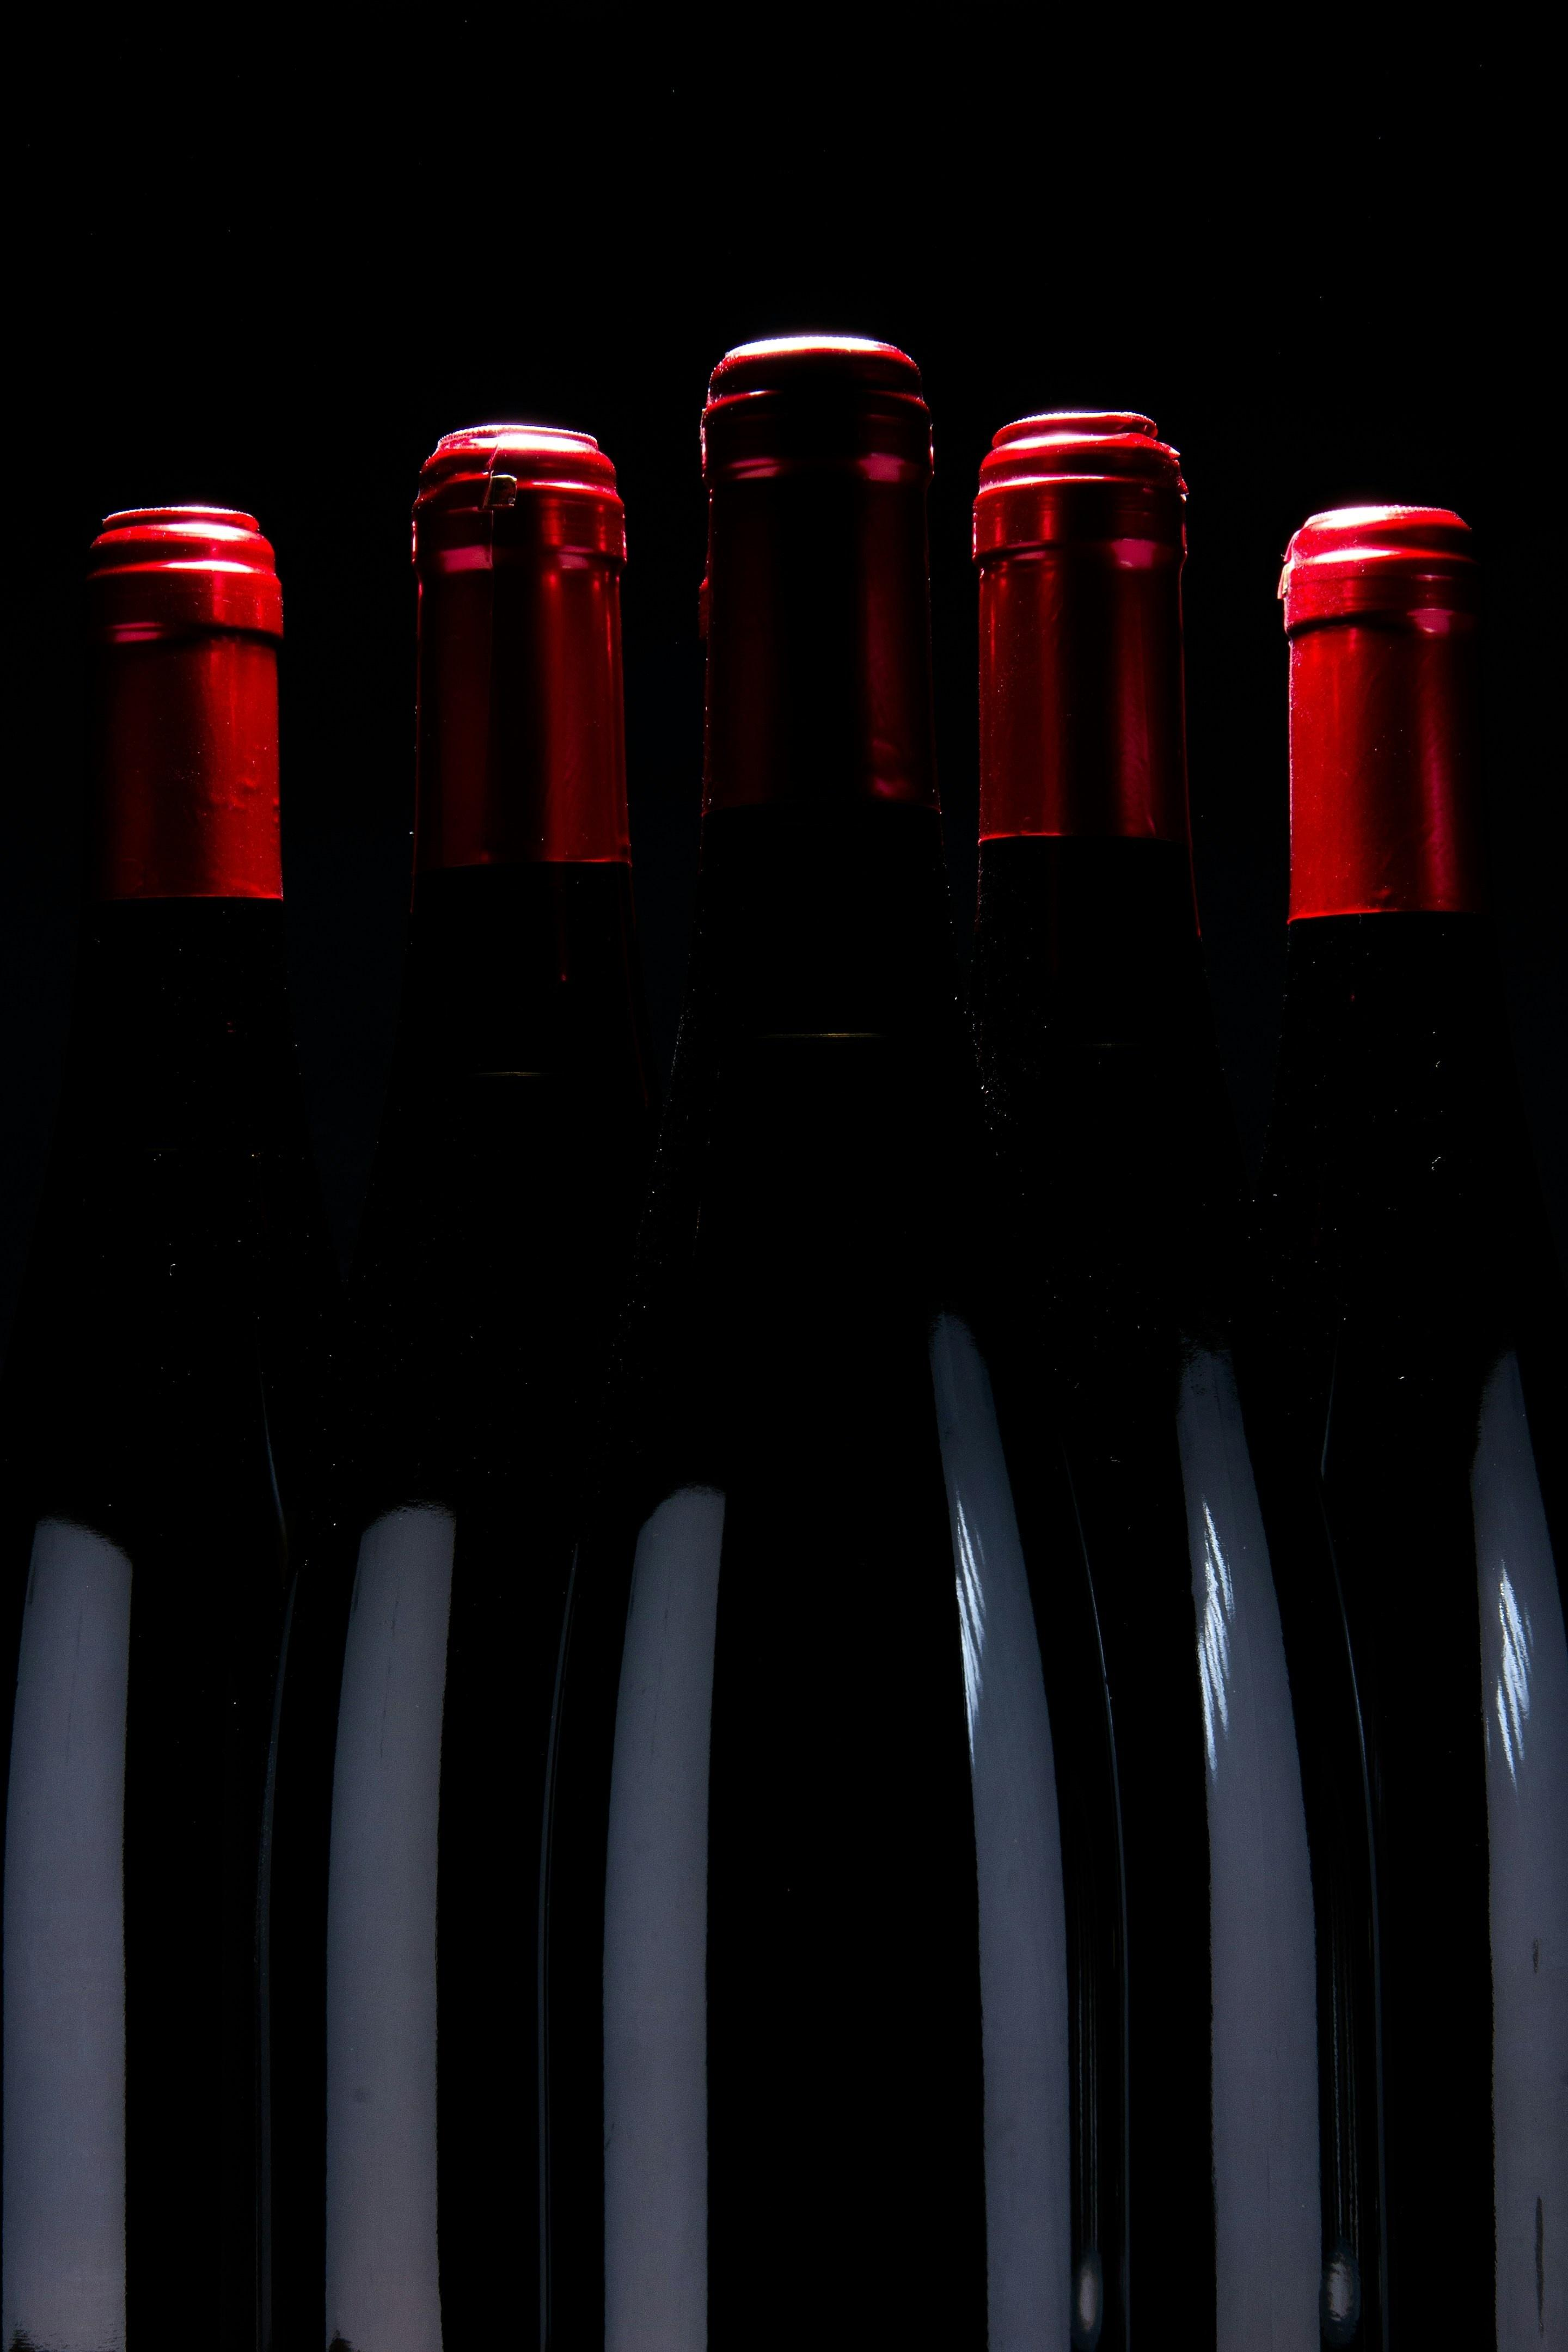

bottle057_jpg.rf.330257f43b8c608d53c7b385d2e91015.jpg


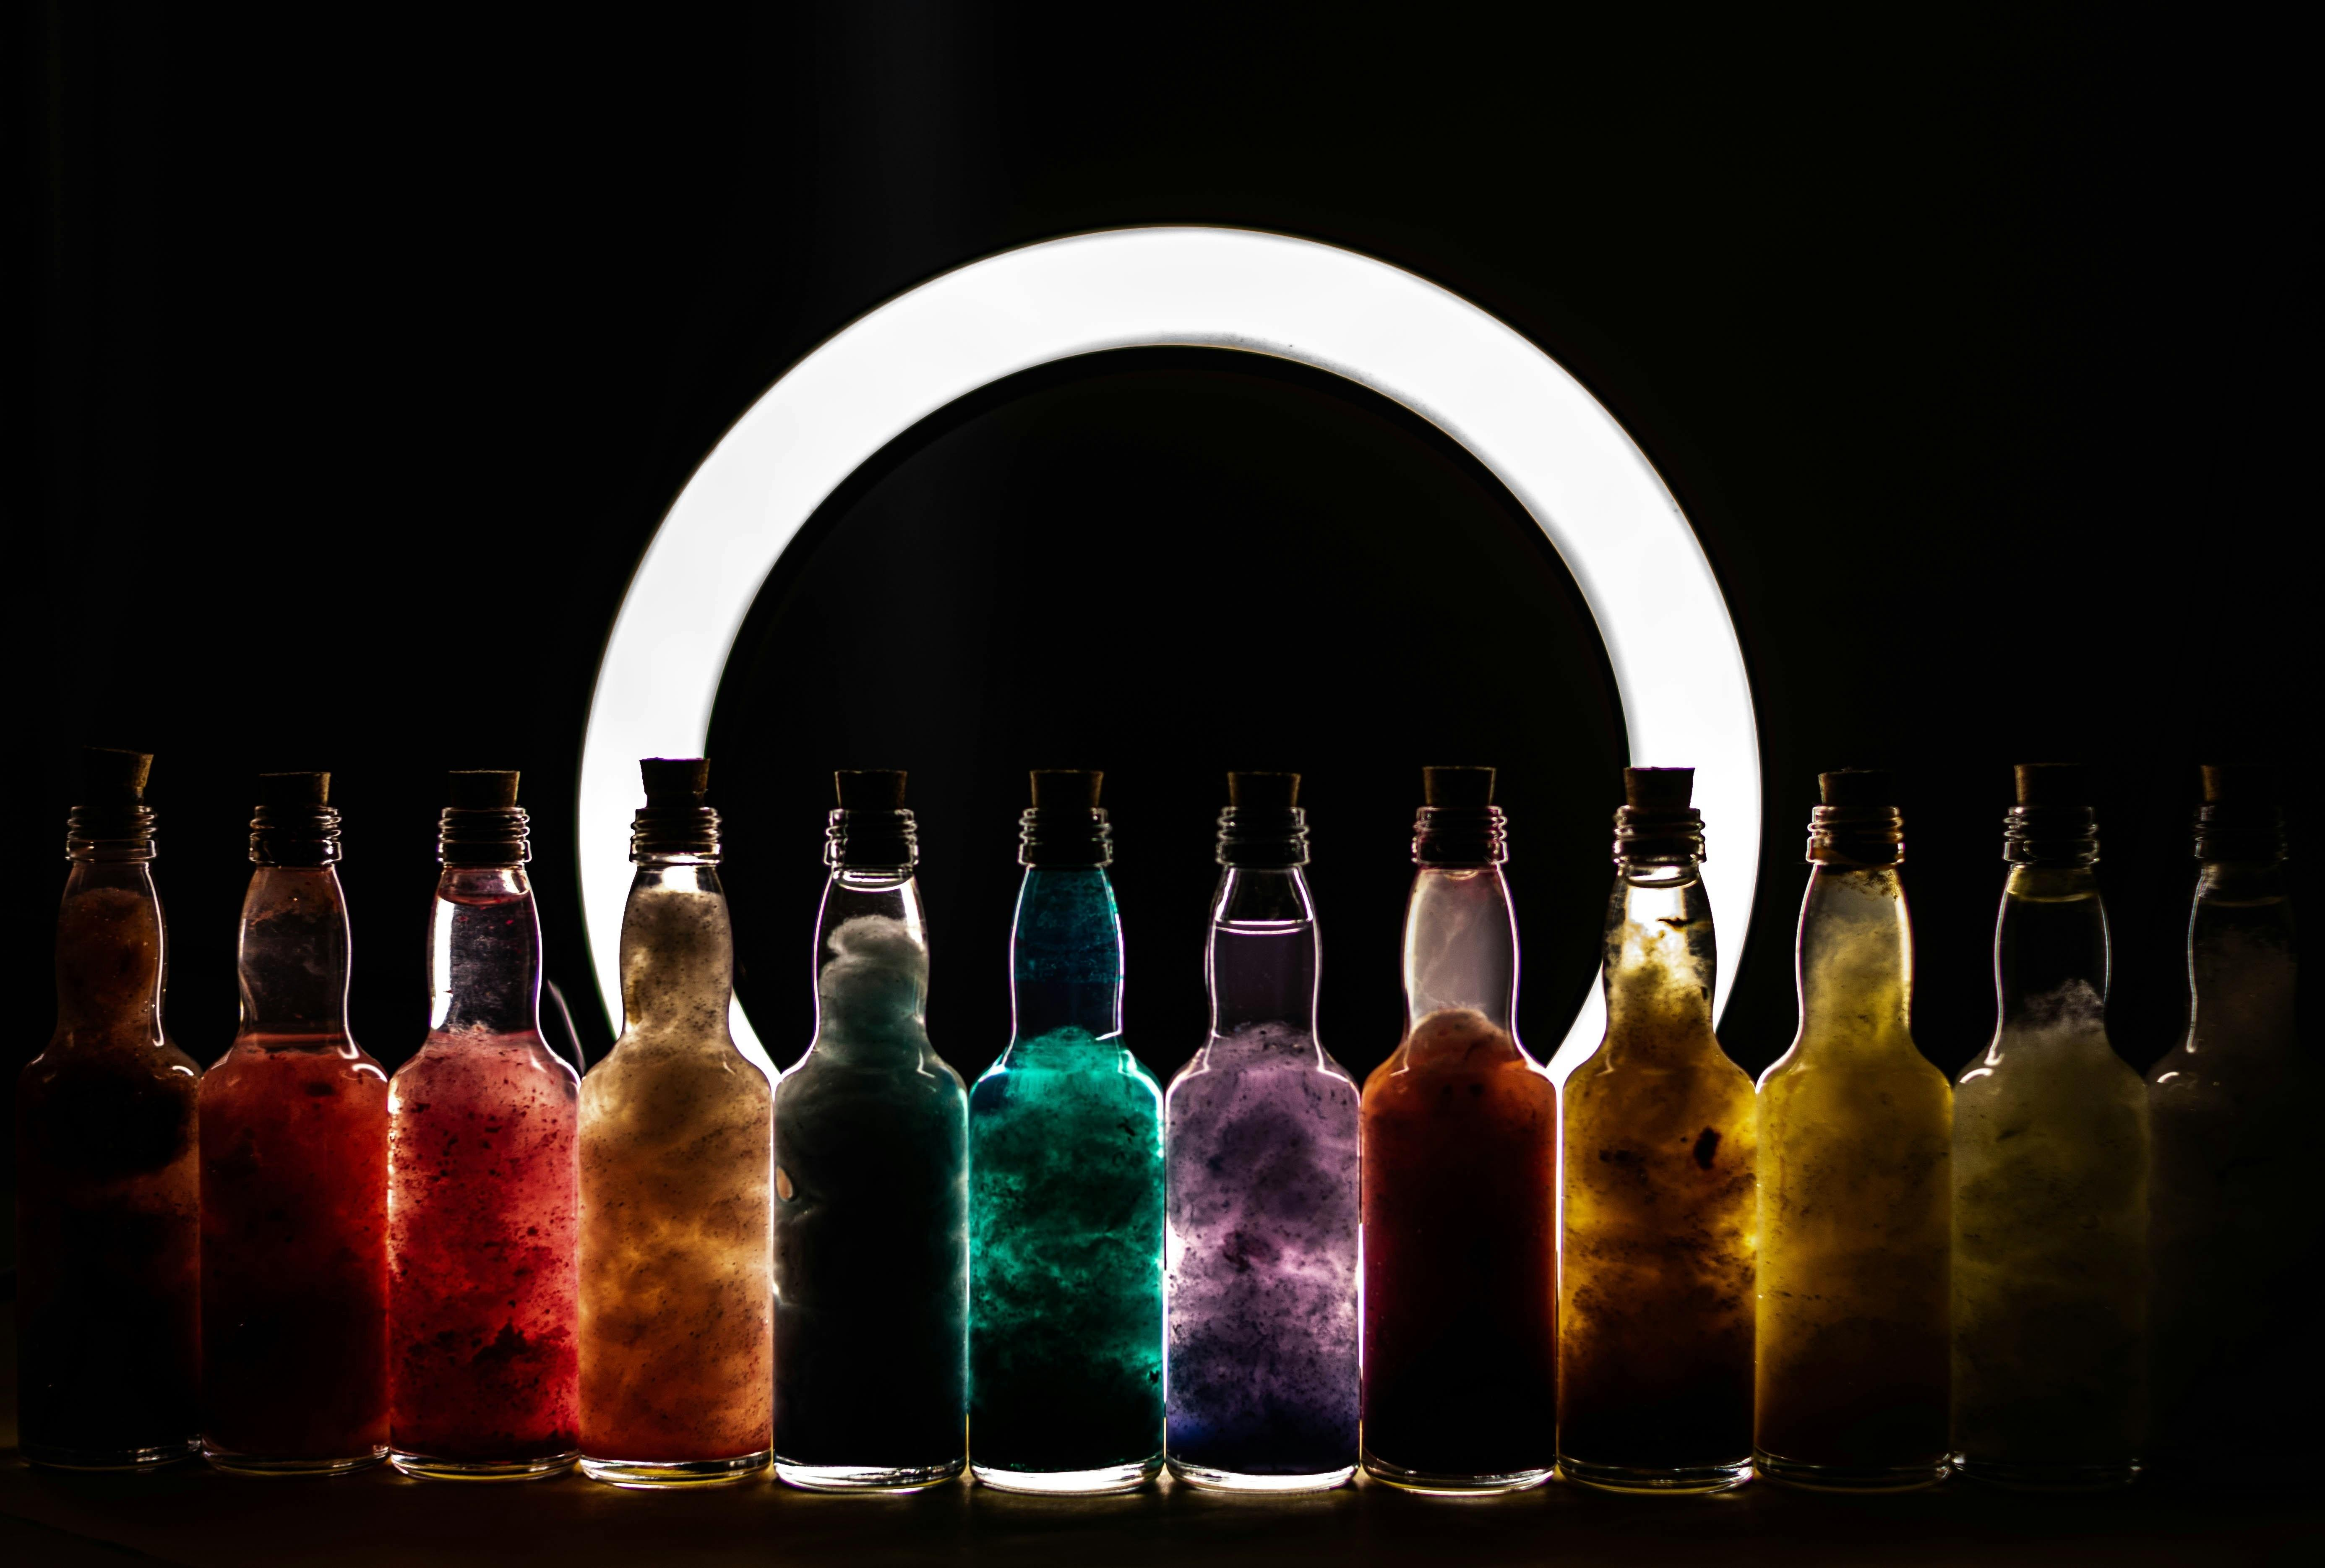

In [50]:
from IPython.display import display, Image

for image_name in difficult_examples["Image"]:

    image_path = os.path.join(
        clean_images,
        image_name
    )

    print(image_name)
    display(Image(filename=image_path, width=500))

In [51]:
final_report = pd.DataFrame({
    "Metric": [
        "Precision",
        "Recall",
        "mAP@50",
        "mAP@50-95",
        "Correct Detections",
        "Missed Detections",
        "False Detections"
    ],
    "Value": [
        precision,
        recall,
        map50,
        map5095,
        correct_total,
        missed_total,
        false_total
    ]
})

final_report

,Metric,Value
0,Precision,0.542940
1,Recall,0.577465
2,mAP@50,0.534867
3,mAP@50-95,0.278880
4,Correct Detections,24.000000
5,Missed Detections,47.000000
6,False Detections,8.000000
